# 08 — MTCNN-croppa nya tillskott till valfritt dataset
**Bakgrund:** appens `prepare_image()` kör alltid `MTCNN(image_size=178, margin=40)` på uppladdade bilder vid inferens. Nya bilder du lägger till i datasetet måste croppas på samma sätt innan träning, annars uppstår samma train/inference-mismatch som löstes tidigare.

**Generell nu** — funkar för både epic-pipelinen (`epic`/`medium`/`thin`) och mustasch-detektor-pipelinen (`mustache`/`clean`). Bara ändra `CLASSES` och `MAIN_DATASET_DIR` i första cellen beroende på vilken du jobbar med.

**Arbetsflöde:**
1. Lägg nya, råa bilder i `data/cropping/<klass>` (klasserna i `CLASSES` nedan)
2. Kör hela notebooken
3. Kontrollera stickprovet i sista cellen
4. Flytta-cellen sammanfogar automatiskt med `MAIN_DATASET_DIR`

**OBS: destruktiv operation på `data/cropping`-mappens innehåll.** Kör backup-cellen först och verifiera att den lyckades innan du fortsätter.

In [49]:
import os
import shutil
import numpy as np
from PIL import Image
from facenet_pytorch import MTCNN

# Pekar på en separat staging-mapp, INTE det befintliga, redan croppade
# måldatasetet — annars riskerar man att köra MTCNN på redan croppade bilder
# igen (kan tappa ansiktsdetektion på en redan hårt beskuren bild).
DATA_DIR   = 'data/cropping'
BACKUP_DIR = 'data/cropping_backup_pre'

# Byt dessa två beroende på vilken pipeline du jobbar med:
CLASSES = ['epic', 'medium', 'thin']         # eller ['mustache', 'clean']
MAIN_DATASET_DIR = 'data/epic_dataset'        # eller 'data/dataset_v3'

mtcnn = MTCNN(image_size=178, margin=40, post_process=False)

print('MTCNN redo. image_size=178, margin=40 — matchar app.py exakt.')
print(f'Klasser: {CLASSES}')
print(f'Mål-dataset: {MAIN_DATASET_DIR}')

MTCNN redo. image_size=178, margin=40 — matchar app.py exakt.
Klasser: ['epic', 'medium', 'thin']
Mål-dataset: data/epic_dataset


## Steg 1 — Backup
Kopierar hela `epic_dataset` innan något skrivs över. Kör bara en gång — om backupen redan finns hoppas den över för att inte råka skriva över en bra backup med redan-croppad data.

In [50]:
if os.path.exists(BACKUP_DIR):
    print(f'Backup finns redan på {BACKUP_DIR} — hoppar över kopiering.')
    print('Om du vill ta en ny backup, ta bort mappen manuellt först.')
else:
    print(f'Kopierar {DATA_DIR} -> {BACKUP_DIR} ...')
    shutil.copytree(DATA_DIR, BACKUP_DIR)
    print('Backup klar!')

def count_images(folder):
    return sum(1 for root, dirs, files in os.walk(folder) for f in files
               if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp')))

print(f'Original: {count_images(DATA_DIR)} bilder')
print(f'Backup:   {count_images(BACKUP_DIR)} bilder')

Backup finns redan på data/cropping_backup_pre — hoppar över kopiering.
Om du vill ta en ny backup, ta bort mappen manuellt först.
Original: 28 bilder
Backup:   45 bilder


## Steg 2 — Samla alla filer
Recursivt genom epic/medium/thin, inklusive undermappar som `pinterest_mustaches`.

In [51]:
def collect_files(folder):
    paths = []
    for root, dirs, files in os.walk(folder):
        for f in files:
            if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp')):
                paths.append(os.path.join(root, f))
    return paths

all_files = collect_files(DATA_DIR)
print(f'Totalt {len(all_files)} bilder att processa.')

Totalt 28 bilder att processa.


## Steg 3 — MTCNN-croppa och skriv över
För varje bild: kör MTCNN, skriv över originalet med croppen om ett ansikte hittas. Om inget ansikte hittas (kan hända på redan hårt beskurna CelebA-bilder) flyttas filen till en granskningsmapp istället för att tystas bort.

In [52]:
NO_FACE_DIR = 'data/cropping_no_face_found'
os.makedirs(NO_FACE_DIR, exist_ok=True)

success_count = 0
no_face_count = 0
error_count = 0

for i, path in enumerate(all_files):
    try:
        img = Image.open(path).convert('RGB')
        face = mtcnn(img)

        if face is not None:
            arr = face.permute(1, 2, 0).numpy().astype(np.uint8)
            cropped = Image.fromarray(arr)
            cropped.save(path)
            success_count += 1
        else:
            dest = os.path.join(NO_FACE_DIR, os.path.basename(path))
            shutil.move(path, dest)
            no_face_count += 1

    except Exception as e:
        print(f'Fel på {path}: {e}')
        error_count += 1

    if (i + 1) % 200 == 0:
        print(f'{i + 1}/{len(all_files)} klara...')

print('\nKlart!')
print(f'Croppade och sparade: {success_count}')
print(f'Inget ansikte hittat (flyttade till {NO_FACE_DIR}): {no_face_count}')
print(f'Fel: {error_count}')


Klart!
Croppade och sparade: 28
Inget ansikte hittat (flyttade till data/cropping_no_face_found): 0
Fel: 0


## Steg 4 — Stickprovskontroll
Visa ett par slumpade bilder från varje klass för att verifiera att croppningen ser rimlig ut innan du tränar om.

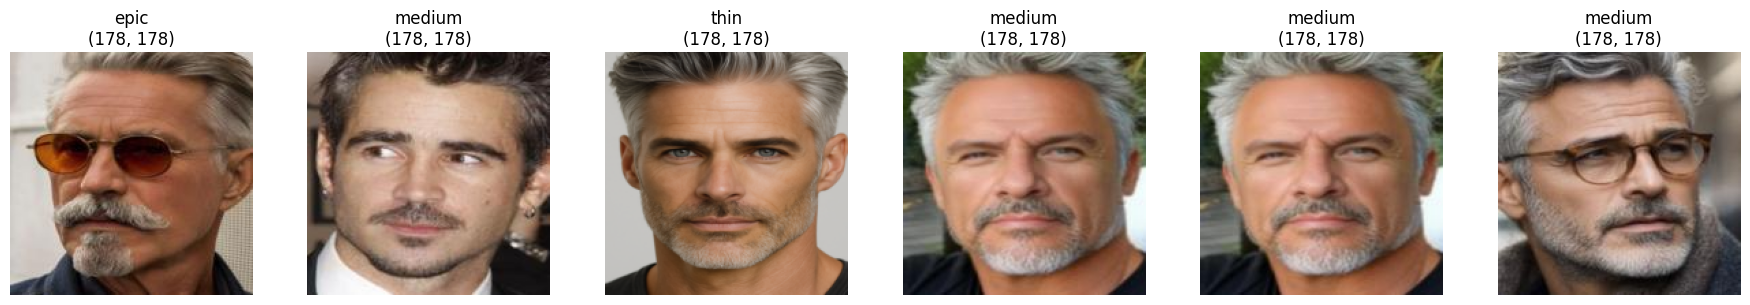

In [53]:
import random
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 6, figsize=(18, 3))

for ax in axes:
    cls = random.choice(CLASSES)
    files = collect_files(os.path.join(DATA_DIR, cls))
    f = random.choice(files)
    img = Image.open(f)
    ax.imshow(img)
    ax.set_title(f'{cls}\n{img.size}')
    ax.axis('off')

plt.tight_layout()
plt.show()

## Steg 5 — Flytta godkända bilder till epic_dataset
Kör bara denna när du är nöjd med stickprovet ovan. Flyttar (inte kopierar) varje croppad bild från `data/cropping/<klass>` till `data/epic_dataset/<klass>`.

In [54]:
moved_count = 0

for cls in CLASSES:
    src_dir = os.path.join(DATA_DIR, cls)
    dst_dir = os.path.join(MAIN_DATASET_DIR, cls)
    os.makedirs(dst_dir, exist_ok=True)

    for fname in os.listdir(src_dir):
        src_path = os.path.join(src_dir, fname)
        if not os.path.isfile(src_path):
            continue
        dst_path = os.path.join(dst_dir, fname)
        shutil.move(src_path, dst_path)
        moved_count += 1

print(f'{moved_count} bilder flyttade till {MAIN_DATASET_DIR}.')
print('Träna om motsvarande modell på den utökade datan.')

28 bilder flyttade till data/epic_dataset.
Träna om motsvarande modell på den utökade datan.


## Nästa steg
Kör om `05e_train_epic_model_3class.ipynb` på den nu MTCNN-konsekventa datan, och testa sedan i `app_3class.py` igen — både på riktiga foton och på samma CelebA-testbilder som visade felet.